# Crypto Perps Funding: Feature Engineering

A perpetual future has no expiry, so the only thing tying it to spot is a payment between its
holders. That payment is the funding rate, it settles every eight hours, and the premium index
it is computed from is published on the same grid. Every feature here is a transformation of
those two series, and the question each one has to answer first is not whether it predicts but
whether it is knowable: at a settlement, which observations have already been published, and
what does the feature make of them?

## Learning objectives

- State a feature's timing contract - its lookback and its information lag - before writing the
  code that computes it
- Move a provider's bar-open clock onto an availability clock, and see why every later shift
  inherits that one decision
- Show that withholding later settlements leaves every feature value unchanged, which separates
  a trailing statistic from one fitted over the whole sample
- Read a feature set for scale, dispersion, redundancy and decay before any model sees it

## Book reference, prerequisites and artifacts

Chapter 8. Reads eight-hourly perpetual bars and the premium index via `load_crypto_perps()`,
the official Binance settlement series via `load_funding_rates()`, and `config/setup.yaml`.
Writes `features/financial.parquet` with a `.digest.json` sidecar, read by
[`04_model_based_features`](04_model_based_features.ipynb), which fits regime and volatility
features on top of it fold by fold, and by [`05_evaluation`](05_evaluation.ipynb), which tests
whether any of it predicts. [`02_labels`](02_labels.ipynb) builds the forward returns on the
same availability clock this notebook uses; nothing here reads a label.

In [1]:
"""Crypto Perps Funding: Feature Engineering."""

import warnings
from datetime import UTC, datetime, timedelta

import numpy as np
import polars as pl
import yaml
from ml4t.engineer.features.ml import percentile_rank_features

from case_studies.crypto_perps_funding.funding_data import load_funding_rates
from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    families_from_config,
    family_coverage,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    trailing_volatility,
    warmup_audit,
)
from data import load_crypto_perps
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("crypto_perps_funding")
FEATURES_DIR = CASE_DIR / "features"

`START_DATE` is unset in production and read below; CI overrides it to shorten the history. The
universe is nineteen symbols and the cross-sectional families need a cross-section to rank
within, so there is no symbol cap.

In [2]:
START_DATE = None

## Configuration

Every window, clip bound, the fee tier, the ranked column and the holdout boundary are declared
in `config/setup.yaml` and bound here. A window typed into a cell is a second copy of a number
the warmup audit and the timing figure both have to agree with, and the two drift apart the first
time either is edited. Each window map reads `suffix: bars`: the emitted names carry hours in
some families and days in others, and that naming is a schema every later stage reads.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
features_cfg = setup["features"]
FAMILIES = families_from_config(setup)
W = features_cfg["windows"]
CLIP = features_cfg["clip"]
MAJORS = set(features_cfg["majors"])
RANKED = features_cfg["ranked"]
REDUNDANCY_CUT = features_cfg["redundancy_cut"]
MIN_CROSS_SECTION = 2
BAR_HOURS = features_cfg["bar_hours"]
BARS_PER_YEAR = setup["evaluation"]["periods_per_year"] * 24 / BAR_HOURS
HOLDOUT_START = datetime.fromisoformat(setup["evaluation"]["holdout_start"]).replace(tzinfo=UTC)
WINDOW_END = datetime.fromisoformat(setup["evaluation"]["holdout_end"]).replace(
    tzinfo=UTC
) + timedelta(days=1)

print(f"{len(FAMILIES)} declared families, {BAR_HOURS}-hour settlement bars")
print(f"Holdout opens {HOLDOUT_START.date()}; Section D rebuilds the panel without it")

6 declared families, 8-hour settlement bars
Holdout opens 2024-01-01; Section D rebuilds the panel without it


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about crowding. When a perpetual trades above the
spot index, longs pay shorts to keep the contract open, and the size of that payment measures
how one-sided the positioning is. A perpetual whose holders are paying most is expected to give
ground relative to the rest of the universe over the following settlements. Three things follow.

The **carrier** is the funding-and-premium block, in four representations rather than one,
because a raw premium is comparable neither across symbols nor across regimes: the level, its
z-score against its own history, its percentile within the settlement, and the speed at which it
decays back. Which of those the effect lives in is a question `05_evaluation` asks.

The **conditioning** is regime. Crowding unwinds differently in a liquidation cascade than in a
quiet week, so the matrix also carries the dispersion of the premium and of the price, the
short-over-long volatility ratios, a sustained-premium indicator and the settlement slot. These
rank nothing against each other; they say which environment a ranking is being formed in, which
is what the register's `role` column records and no assertion can recover from the values.

The **failure modes** are stated with the families rather than discovered later: the exchange
clamps the funding rate, so the carrier saturates in the regimes that matter most, and momentum
and mean reversion read one series with opposite signs, so a model given both may find they
cancel. Every lag in the register is zero, and Section B is where that is earned.

In [4]:
register_frame(FAMILIES).select(["family", "role", "inputs", "lookback (bars)", "lag (bars)"])

family,role,inputs,lookback (bars),lag (bars)
str,str,str,i64,i64
"""carry""","""signal""","""official funding settlements, …",43,0
"""mean_reversion""","""signal""","""premium index close""",90,0
"""momentum""","""signal""","""premium index close""",90,0
"""volatility""","""state""","""premium index close, perpetual…",43,0
"""cross_sectional""","""state""","""premium index close, official …",1,0
"""regime""","""state""","""premium index close, symbol, d…",10,0


## B. Inputs and their observability

Binance stamps each kline with the time its bar **opened**, so a row stamped midnight reports a
close, a volume and a premium index that nobody knows until eight hours later. The series is
advanced by one bar length before anything is joined, shifted or filtered, and the resulting
`timestamp` is the boundary at which the completed bar is available.
[`02_labels`](02_labels.ipynb) advances it the same way, so a feature row and a label row
carrying one timestamp describe one decision.

The official settlement series needs no such shift. Its `calc_time` is the settlement instant
itself, and the rate is the time-weighted premium over the interval ending there plus the
interest component and the exchange clamp - so the newest input to `funding_rate` at a
timestamp is dated at that timestamp. The last line below is what would catch that being wrong:
a rate determined by the interval that ends at its own stamp tracks the return over that
interval, and a rate stamped a bar early would instead track the one that follows it.

In [5]:
available_at = (pl.col("timestamp") + pl.duration(hours=BAR_HOURS)).alias("timestamp")
prices = (
    load_crypto_perps(frequency=f"{BAR_HOURS}h", start_date=START_DATE)
    .with_columns(available_at)
    .filter(pl.col("timestamp") < WINDOW_END)
    .sort(["symbol", "timestamp"])
)
funding = load_funding_rates(symbols=prices["symbol"].unique().to_list())
required = {"open", "high", "low", "close", "volume", "premium_index_close"}
assert not required - set(prices.columns), (
    f"loader missing {sorted(required - set(prices.columns))}"
)

# The trailing seven days of settlements are summed on the funding series' own clock rather than
# as a fixed row count on the eight-hour panel, because Binance can shorten one contract's
# settlement interval to two or four hours and a fixed-row sum would then omit real cash flows.
cashflow_label, cashflow_days = next(iter(W["funding_cashflow"].items()))
cashflows = (
    funding.with_columns(pl.col("funding_rate").clip(lower_bound=0.0).alias("_paid"))
    .rolling(
        index_column="timestamp", period=f"{cashflow_days}d", group_by="symbol", closed="right"
    )
    .agg(pl.col("_paid").sum().alias(f"cum_positive_funding_{cashflow_label}"))
)
panel = prices.join(
    funding.select("timestamp", "symbol", "funding_rate"), on=["timestamp", "symbol"], how="left"
).join(cashflows, on=["timestamp", "symbol"], how="left")
observability = panel.sort(["symbol", "timestamp"]).select(
    pl.corr(pl.col("funding_rate"), pl.col("close").log().diff().over("symbol")).alias("backward"),
    pl.corr(
        pl.col("funding_rate"), pl.col("close").log().diff().over("symbol").shift(-1).over("symbol")
    ).alias("forward"),
)
print(f"{len(panel):,} settlement bars over {panel['symbol'].n_unique()} perpetuals")
print(f"{panel['funding_rate'].is_not_null().mean():.4%} of them carry an official settlement")
print(f"{funding.filter(pl.col('funding_interval_hours') != BAR_HOURS).height} shortened intervals")
print(f"funding against the interval it is computed from: {observability['backward'][0]:+.4f}")
print(f"funding against the interval that follows it:     {observability['forward'][0]:+.4f}")

108,298 settlement bars over 19 perpetuals
99.6833% of them carry an official settlement
101 shortened intervals
funding against the interval it is computed from: +0.0586
funding against the interval that follows it:     -0.0005


## C. Feature construction, one subsection per family

### C.1 Carry: the funding rate and the premium it is computed from

The z-score is the shared trailing primitive: mean and dispersion over the row's own history,
with the one denominator guard the stage uses everywhere. Its clip is not a guard but a decision
the configuration declares, because a settlement-day outlier otherwise sets the scale a model
reads. The half-life is local, since no library call covers it: the decay time implied by a
rolling AR(1) coefficient, built from a trailing covariance and a trailing variance so nothing
is estimated across the sample, clipped where the coefficient approaches one and the implied
half-life diverges.

Two details of it are worth stating, because both were wrong in the shipped version and in
opposite directions. Its denominator is guarded on being **positive** rather than clipped at the
stage's shared `EPS`. `EPS` is the right guard where the two sides of a ratio are on comparable
scales; here the denominator is the variance of a rate whose typical magnitude is a basis point,
so its median over this panel is around seven parts in a billion - below `EPS` - and clipping
there stops being a guard and becomes the floor that sets the answer on most rows.

And a coefficient that cannot be estimated has no single sensible default, so each case is named
rather than swept into one `otherwise`. Before the trailing moments exist the column is null. A
coefficient of exactly zero is a series that has **already** reverted, so its half-life is the
configured floor - routing it to the window length instead, as the shipped version did, reports
the least persistent rows as the slowest to decay.

In [6]:
def carry_features(df: pl.DataFrame) -> pl.DataFrame:
    """Funding and premium level, dispersion-normalized, and the reversion speed."""
    z = CLIP["zscore"]
    df = df.with_columns(
        [
            rolling_zscore("premium_index_close", bars, "symbol")
            .clip(-z, z)
            .alias(f"premium_zscore_{label}")
            for label, bars in W["premium_zscore"].items()
        ]
        + [
            rolling_zscore("funding_rate", bars, "symbol")
            .clip(-z, z)
            .alias(f"funding_rate_zscore_{label}")
            for label, bars in W["funding_zscore"].items()
        ]
        + [pl.col("premium_index_close").alias("premium_level")]
    )
    for label, bars in W["funding_half_life"].items():
        df = funding_moments(df, bars).with_columns(
            half_life(bars, clip_variance=False, zero_to_window=False).alias(
                f"funding_half_life_{label}"
            )
        )
    return df.drop("_cov", "_var")


def funding_moments(df: pl.DataFrame, bars: int) -> pl.DataFrame:
    """Trailing covariance of the settlement series with its own lag, and the lag's variance."""
    lagged = pl.col("funding_rate").shift(1).over("symbol")
    return df.with_columns(
        (
            (pl.col("funding_rate") * lagged).rolling_mean(bars).over("symbol")
            - pl.col("funding_rate").rolling_mean(bars).over("symbol")
            * lagged.rolling_mean(bars).over("symbol")
        ).alias("_cov"),
        lagged.rolling_var(bars, ddof=0).over("symbol").alias("_var"),
    )


def half_life(bars: int, *, clip_variance: bool, zero_to_window: bool) -> pl.Expr:
    """Half-life implied by the trailing AR(1) coefficient, with two defects switchable.

    Neither flag reproduces a particular past revision; each reproduces a way this estimator
    can be wrong, so the cell below can assert against each rather than against a fixture
    written beside the fix.
    """
    floor, ceiling = CLIP["half_life"]
    if clip_variance:
        # A denominator floored rather than guarded: the clip stands in for a positivity test,
        # so a non-positive variance still divides and still yields a value rather than a null.
        rho = (pl.col("_cov") / pl.col("_var").clip(lower_bound=EPS)).clip(
            -CLIP["ar1"], CLIP["ar1"]
        )
    else:
        rho = (
            pl.when(pl.col("_var") > 0)
            .then(pl.col("_cov") / pl.col("_var"))
            .clip(-CLIP["ar1"], CLIP["ar1"])
        )
    if zero_to_window:
        # A near-zero coefficient routed to the window length, with the inner log clip that
        # kind of branch travels with.
        return (
            pl.when(rho.is_null())
            .then(None)
            .when(rho.abs() > 1 / bars)
            .then(-np.log(2) / rho.abs().log().clip(lower_bound=-10))
            .otherwise(pl.lit(float(bars)))
            .clip(floor, ceiling)
        )
    return (
        pl.when(rho.is_null())
        .then(None)
        .when(rho == 0)
        .then(pl.lit(floor))
        .otherwise(-np.log(2) / rho.abs().log())
        .clip(floor, ceiling)
    )

Neither choice above is pinned by the warmup audit or by the seal: both pass with the denominator
floored again, or with a near-zero coefficient routed back to the window length. A test file could
only re-implement the expression, since it lives in this cell, and would agree with whatever it
was written beside. So both defects stay switchable, and each is asserted against separately on
the production panel - an assertion that catches one of them says nothing about the other, which
is how the first version of this check passed while the denominator was still floored.

In [7]:
_bars = W["funding_half_life"]["14d"]
_sorted = panel.sort(["symbol", "timestamp"])
# `now` is read out of `carry_features` rather than recomputed here. Recomputing it with the flags
# spelled out would make this cell agree with itself and pass however `carry_features` was edited,
# which is the failure it exists to catch.
_v = funding_moments(_sorted, _bars).select(
    carry_features(_sorted)["funding_half_life_14d"].alias("now"),
    half_life(_bars, clip_variance=True, zero_to_window=False).alias("eps_clipped"),
    half_life(_bars, clip_variance=True, zero_to_window=True).alias("both_defects"),
    ((pl.col("_var") > 0) & (pl.col("_var") < EPS)).alias("thin"),
)
_thin = _v.filter(pl.col("thin"))
_differs = (_thin["now"] - _thin["eps_clipped"]).abs() > 1e-9
# A warmup row has no coefficient to revert, so it cannot show the defect. Counting the warmup as
# window-length hits is what let the last assertion below pass without a single reverted coefficient.
_estimated = _v.filter(pl.col("both_defects").is_not_null())
_at_window = (_estimated["both_defects"] == float(_bars)).mean()
assert (_v["now"] == float(_bars)).sum() == 0, "a reverted coefficient reports the window length"
assert _differs.mean() > 0.5, "the variance is being clipped: thin rows agree with the EPS oracle"
assert _at_window > 0.01, "no row reaches the window length carrying both defects"
print(f"variance below the shared guard on {_v['thin'].mean():.2%} of rows")
print(f"  of those, {_differs.mean():.2%} would move if the denominator were clipped there")
print(f"at the window length, of rows with a coefficient: {_at_window:.2%} with both, 0 now")

variance below the shared guard on 56.50% of rows
  of those, 59.22% would move if the denominator were clipped there
at the window length, of rows with a coefficient: 17.11% with both, 0 now


### C.2 Mean reversion: where the premium sits in its own recent range

The rolling percentile is `ml4t.engineer.features.ml.percentile_rank_features`, which ranks the
current premium against the window that ends at it. It is a *time-series* percentile, not a
cross-sectional one - it answers "high for this symbol lately", where C.5 answers "high against
what everyone else is paying now" - and the two are separate features because they disagree
whenever the whole universe moves together.

In [8]:
def mean_reversion_features(df: pl.DataFrame) -> pl.DataFrame:
    """Deviation from a trailing mean, position in the trailing distribution, sign persistence."""
    windows = W["premium_quantile"]
    ranks = percentile_rank_features(RANKED, windows=list(windows.values()))
    return df.with_columns(
        [
            (pl.col(RANKED) - pl.col(RANKED).rolling_mean(bars).over("symbol")).alias(
                f"premium_dev_mean_{label}"
            )
            for label, bars in W["premium_dev_mean"].items()
        ]
        + [
            ranks[f"rank_{bars}"].over("symbol").alias(f"premium_quantile_pos_{label}")
            for label, bars in windows.items()
        ]
        + [
            (pl.col(RANKED) > 0)
            .cast(pl.Float64)
            .rolling_mean(bars)
            .over("symbol")
            .alias(f"premium_persistence_{label}")
            for label, bars in W["premium_persistence"].items()
        ]
    )

### C.3 Momentum: how the premium got where it is

Six trailing differences, and two differences between them. The acceleration terms compare a
short window against a longer one, so a premium that widened last settlement but has been
narrowing all week reads differently from one doing both.

In [9]:
def momentum_features(df: pl.DataFrame) -> pl.DataFrame:
    """Premium differences at six horizons, the funding-rate change, and two accelerations."""
    horizons = W["premium_momentum"]
    df = df.with_columns(
        [
            (pl.col(RANKED) - pl.col(RANKED).shift(bars).over("symbol")).alias(
                f"premium_change_{label}"
            )
            for label, bars in horizons.items()
        ]
        + [
            (pl.col("funding_rate") - pl.col("funding_rate").shift(bars).over("symbol")).alias(
                f"funding_rate_change_{label}"
            )
            for label, bars in W["funding_change"].items()
        ]
    )
    short, medium, long = list(horizons)[1:4]
    return df.with_columns(
        (pl.col(f"premium_change_{short}") - pl.col(f"premium_change_{medium}")).alias(
            "premium_accel_short"
        ),
        (pl.col(f"premium_change_{medium}") - pl.col(f"premium_change_{long}")).alias(
            "premium_accel_medium"
        ),
    )

### C.4 Volatility: two dispersions that are not the same quantity

Price volatility is the shared trailing primitive on the perpetual's log return, annualized at
the case study's own bar count so it is on the scale a volatility is read on and comparable with
the other eight case studies. Premium volatility stays local and unannualized: the premium index
is a rate in its own units rather than a return, so a root-time factor would put a number on it
that does not mean what an annualized volatility means.

In [10]:
def volatility_features(df: pl.DataFrame) -> pl.DataFrame:
    """Trailing dispersion of the premium and of the price, plus short-over-long ratios."""
    df = df.with_columns(
        [
            pl.col("_premium_change").rolling_std(bars).over("symbol").alias(f"premium_vol_{label}")
            for label, bars in W["premium_volatility"].items()
        ]
        + [
            trailing_volatility(
                "_log_return", bars, "symbol", periods_per_year=BARS_PER_YEAR
            ).alias(f"price_vol_{label}")
            for label, bars in W["price_volatility"].items()
        ]
    )
    short, medium, long, longest = list(W["premium_volatility"])
    cap = CLIP["vol_ratio"]
    return df.with_columns(
        (pl.col(f"premium_vol_{short}") / pl.col(f"premium_vol_{long}").clip(lower_bound=EPS))
        .clip(upper_bound=cap)
        .alias("vol_ratio_short"),
        (pl.col(f"premium_vol_{medium}") / pl.col(f"premium_vol_{longest}").clip(lower_bound=EPS))
        .clip(upper_bound=cap)
        .alias("vol_ratio_medium"),
    )

### C.5 Cross-sectional position within one settlement

Three statistics taken with `.over("timestamp")`, so each reads every symbol trading at that
settlement and no other date. The percentile uses the shared primitive, whose denominator is the
count plus one: that keeps the widest-premium perpetual off the boundary, so the column is a
position in the cross-section rather than a rank divided by its own maximum, and it means the
same thing on an early date with three symbols as on a late one with nineteen.

In [11]:
def cross_sectional_features(df: pl.DataFrame) -> pl.DataFrame:
    """Distance from the settlement's median, its z-score, and the dispersion of funding paid."""
    return df.with_columns(
        (pl.col(RANKED) - pl.col(RANKED).median().over("timestamp")).alias("premium_vs_median"),
        (
            (pl.col(RANKED) - pl.col(RANKED).mean().over("timestamp"))
            / pl.col(RANKED).std().over("timestamp").clip(lower_bound=EPS)
        )
        .clip(-CLIP["zscore"], CLIP["zscore"])
        .alias("premium_xs_zscore"),
        pl.col("funding_rate").std().over("timestamp").alias("xs_funding_dispersion"),
    )

### C.6 Regime and calendar

The oscillator would be `ml4t.engineer.features.momentum.rsi`, and is computed here instead. That
call carries Wilder's recursive average, which cannot resume after a missing observation: on this
premium series it returns the saturated value on four rows in five, where an average taken over a
fixed window returns nothing while the window spans a gap and a usable number once it has passed.
The two are different statistics, so this one is not called a Wilder RSI.

The settlement slot and the fee tier are the two columns with no lookback at all: the slot is a
property of the timestamp, and the tier is a fixed list the configuration declares.

In [12]:
def regime_features(df: pl.DataFrame) -> pl.DataFrame:
    """Sustained-premium indicator, bounded oscillators, settlement slot and fee tier."""
    return df.with_columns(
        [
            pl.when(pl.col(RANKED) > 0)
            .then(1.0)
            .otherwise(-1.0)
            .rolling_mean(bars)
            .over("symbol")
            .alias(f"premium_regime_{label}")
            for label, bars in W["premium_regime"].items()
        ]
        + [
            (
                100
                - 100
                / (
                    1
                    + pl.col("_premium_change")
                    .clip(lower_bound=0)
                    .rolling_mean(bars)
                    .over("symbol")
                    / (-pl.col("_premium_change"))
                    .clip(lower_bound=0)
                    .rolling_mean(bars)
                    .over("symbol")
                    .clip(lower_bound=EPS)
                )
            ).alias(f"premium_rsi_{label}")
            for label, bars in W["premium_rsi"].items()
        ]
        + [
            (pl.col("timestamp").dt.hour() // BAR_HOURS).cast(pl.Int32).alias("funding_session"),
            pl.when(pl.col("symbol").is_in(list(MAJORS)))
            .then(0)
            .otherwise(1)
            .cast(pl.Int32)
            .alias("cost_tier_alt"),
        ]
    )

### C.7 The order the three steps run in

Everything above is computed from one perpetual's own history. The four within-settlement
statistics are not, and that puts the null policy **between** them rather than after both. A
percentile, a median and a dispersion are properties of the cross-section they are taken over, so
a perpetual the matrix will not carry must not be in that cross-section: including it moves the
number written for every perpetual that is. Running the gate last is the shape `etfs` documents,
and it is what this notebook did until the ordering was measured - at the settlement of
2020-01-31 the emitted cross-section holds two perpetuals, and `premium_rank` was a position
among five.

Ordering the two steps this way decides which cross-section is read; it does not yet say that
there is one. The z-score and the dispersion are both standard deviations over the settlement,
which one observation does not define, so a settlement where the gate leaves a single perpetual
has no value to write for either. Emitting a null there and then asserting the matrix has none is
a contradiction the panel reaches whenever the surviving cross-section narrows to one, so the
gate takes `MIN_CROSS_SECTION` as its second clause and that settlement does not reach the matrix.
A median and a percentile are defined at one observation and are dropped with it: they are
properties of the same cross-section, and keeping the row for the two columns that survive would
ship a settlement whose position statistics have nothing to be a position among.

In [13]:
def per_symbol_features(df: pl.DataFrame) -> pl.DataFrame:
    """Everything computed from one perpetual's own history, before any gate."""
    return (
        df.sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col(RANKED) - pl.col(RANKED).shift(1).over("symbol")).alias("_premium_change"),
            pl.col("close").log().diff().over("symbol").alias("_log_return"),
        )
        .pipe(carry_features)
        .pipe(mean_reversion_features)
        .pipe(momentum_features)
        .pipe(volatility_features)
        .pipe(regime_features)
    )


def build_features(df: pl.DataFrame) -> pl.DataFrame:
    """The whole construction, as one function Section D can re-run on a shorter panel."""
    trailing = per_symbol_features(df)
    eligible = trailing.drop_nulls(subset=[c for c in SYMBOL_COLS if c in trailing.columns])
    contested = eligible.filter(pl.len().over("timestamp") >= MIN_CROSS_SECTION)
    return contested.pipe(cross_sectional_features).with_columns(
        cross_sectional_percentile(RANKED, "timestamp").alias("premium_rank")
    )


# The two carry columns are joined in Section B and shipped as features, so they are added back
# to the input frame's own columns before the difference; taking the difference alone drops them.
CARRIED = {"funding_rate", f"cum_positive_funding_{cashflow_label}"}
EXCLUDED = (set(panel.columns) | {"_premium_change", "_log_return"}) - CARRIED
XS_COLS = ["premium_vs_median", "premium_xs_zscore", "xs_funding_dispersion", "premium_rank"]

trailing = per_symbol_features(panel)
SYMBOL_COLS = sorted(c for c in trailing.columns if c not in EXCLUDED)
built = build_features(panel)
feature_cols = sorted(assign_families(SYMBOL_COLS + XS_COLS, FAMILIES))
print(f"{len(trailing):,} bars carrying {len(SYMBOL_COLS)} per-symbol features")
print(f"{len(built):,} pass the gate and carry the {len(XS_COLS)} within-settlement features")

108,298 bars carrying 35 per-symbol features
99,877 pass the gate and carry the 4 within-settlement features


## D. The timing contract

### D.1 What each construction reads

Three kinds of operation appear above. A **rolling** window ends at its own row and reads a fixed
number of settlements backward, always `.over("symbol")`, so a shift means "the previous
settlement for this perpetual" and never "the previous row in the file". A **cross-sectional**
statistic - the three in C.5 and the percentile - is taken with `.over("timestamp")`, so it reads
every perpetual at that settlement and no other date. A **time-based rolling** aggregate builds
the seven-day cash flow on the settlement series' own clock, which is what lets it span an
interval the exchange shortened. None of the three reaches forward, and D.2 and D.3 establish it
rather than asserting it.

### D.2 Warmup

A trailing window cannot produce a value until it has enough settlements to fill, so every family
has a leading stretch of nulls as long as its lookback. The audit checks that length rather than
describing it: a column holding a value before its window could have filled is reading bars that
do not exist, and that is what it raises on. It caught one here - the half-life fell through to
its own fallback while its covariance was still null, so it reported a reversion speed on every
bar from the first, and C.1 now returns null until the window has filled.

It runs on the panel before the gate, because the gate drops the warmup stretch it measures.

In [14]:
warmup_audit(
    trailing,
    {
        "premium_change_720h": W["premium_momentum"]["720h"],
        "premium_quantile_pos_30d": W["premium_quantile"]["30d"],
        "premium_zscore_14d": W["premium_zscore"]["14d"],
        "funding_rate_zscore_14d": W["funding_zscore"]["14d"],
        "funding_half_life_14d": W["funding_half_life"]["14d"],
        "price_vol_14d": W["price_volatility"]["14d"],
        "premium_vol_336h": W["premium_volatility"]["336h"],
        "vol_ratio_medium": W["premium_volatility"]["336h"],
        "premium_regime_72h": W["premium_regime"]["72h"],
    },
    entity="symbol",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""premium_change_720h""",90,91,true
"""premium_quantile_pos_30d""",90,90,true
"""premium_zscore_14d""",42,42,true
"""funding_rate_zscore_14d""",42,42,true
"""funding_half_life_14d""",42,43,true
"""price_vol_14d""",42,43,true
"""premium_vol_336h""",42,43,true
"""vol_ratio_medium""",42,43,true
"""premium_regime_72h""",9,9,true


### D.3 Withholding the holdout changes nothing

Trailing and within-settlement statistics share a property worth checking directly: recomputed on
a panel that stops before the holdout, they reproduce the same values on the rows the two panels
share. A parameter fitted over a whole column - a winsorization bound, a scaler, an encoder -
does not, because truncating the column moves the parameter and with it every row it was applied
to. Building the panel twice tests the whole construction at once, every emitted column rather
than a sample, and does not depend on anyone having flagged the transform that fits. A value on
one side against a null on the other counts as a difference, which is the form of the failure a
null-skipping comparison hides.

In [15]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(panel.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=["timestamp", "symbol"],
)
seal.filter(pl.col("column").is_in(["premium_rank", "premium_xs_zscore", "funding_half_life_14d"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""funding_half_life_14d""",59002,0,0.0
"""premium_rank""",59002,0,0.0
"""premium_xs_zscore""",59002,0,0.0


## E. Matrix assembly and coverage

The panel key is `symbol` + `timestamp`. The raw open, high, low, close, volume and premium index
are excluded: they are the inputs the features are made of, and a model handed the
contemporaneous close beside a label derived from the same price would be reading its own answer.
So are the two intermediates the construction passes between subsections. `premium_level` is the
deliberate exception, the premium index under a name that says it is shipped as a signal.

One null policy is applied once, and C.7 is where: a row reaches the matrix only when every
per-symbol feature on it is observed and its settlement retains the two perpetuals a
within-settlement statistic needs, and those statistics are then taken over exactly the rows that
survived. A model handed a null has to be told what to do with it, and the successor stages
include sequence models with no answer, so a matrix that carries every feature on every row it
emits is worth more here than the rows a looser rule recovers - and the assertion below is what
makes that a fact rather than an intention.

It is worth being exact about what that does and does not buy, because the two are easy to run
together. Every emitted row is complete. The emitted settlements are **not** consecutive: this
gate removes rows, and the paragraph below is the measurement of how many. The sequence stages
build their windows by position within each symbol's sorted rows
(`case_studies/utils/sequence_dataset.py`), so a window closes over whatever rows are adjacent in
that array and can span a removed settlement. That is a property of the panel the premium index
already forces - one missing observation empties a thirty-day window - and not something the
second clause introduces: it removes whole settlements, and on the shipped nineteen-perpetual
panel it removes none.

What that costs is worth reading rather than absorbing, because almost none of it is warmup. The
perpetual close and its volume are complete, but the premium index has scattered gaps, and one
missing observation empties every rolling window spanning it - so the thirty-day percentile loses
ninety settlements per gap where a thirty-day difference loses one.

In [16]:
features = built.select(["timestamp", "symbol", *feature_cols]).sort(["timestamp", "symbol"])
assert features.select(["timestamp", "symbol"]).is_duplicated().sum() == 0, "duplicate panel key"
incomplete = {c: features[c].null_count() for c in feature_cols if features[c].null_count()}
assert not incomplete, f"the gate left nulls behind: {incomplete}"
gaps = panel["premium_index_close"].is_null().sum()
print(f"{trailing.height:,} bars assembled, {features.height:,} complete on every feature")
print(f"{gaps:,} premium-index gaps in the input, {trailing.height - features.height:,} discarded")
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

108,298 bars assembled, 99,877 complete on every feature
537 premium-index gaps in the input, 8,421 discarded


family,columns,role,representation
str,i64,str,str
"""carry""",9,"""signal""","""level, trailing z-score, cross…"
"""mean_reversion""",6,"""signal""","""deviation from a trailing mean…"
"""momentum""",8,"""signal""","""differences at six horizons, p…"
"""volatility""",8,"""state""","""trailing dispersion at four ho…"
"""cross_sectional""",3,"""state""","""distance from the cross-sectio…"
"""regime""",5,"""state""","""signed regime average, bounded…"


### F1. Coverage through time

Coverage is drawn on the panel the gate acts on rather than on the emitted matrix. On the emitted
matrix it is a check that the policy ran - flat lines at exactly one, by construction, and nothing
else to see. Drawn on what the gate reads, it shows which family loses which months, and how much
of the discarded seven percent is warmup at the left edge against premium-index gaps spread
through the sample. The cross-sectional family is absent because it does not exist yet at this
point: C.7 computes it after the gate, over the rows that survived.

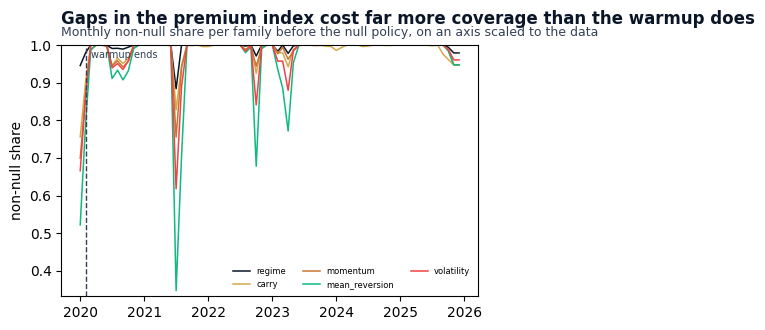

In [17]:
plot_coverage_through_time(
    family_coverage(
        trailing, {c: f for c, f in assignment.items() if c in SYMBOL_COLS}, every="1mo"
    ),
    warmup_boundary=features["timestamp"].min(),
    title="Gaps in the premium index cost far more coverage than the warmup does",
    subtitle="Monthly non-null share per family before the null policy, on an axis scaled to the data",
    alt=(
        "Line chart of non-null share against date for the five per-symbol families - carry, mean "
        "reversion, momentum, volatility and regime - on a y-axis running from about 0.35 to one. "
        "Every family sits at one for most months. The dips are sharp, isolated, and scattered "
        "from 2020 to 2023 rather than gathered at the warmup boundary marked at the left edge; "
        "the deepest is mid-2021, where mean reversion falls to about 0.35 and volatility to "
        "about 0.6, and there is a shallower one at the end of 2025. Mean reversion falls "
        "furthest at every dip because its longest window is the thirty-day percentile, and the "
        "other four follow it down by progressively less in the same months."
    ),
)

### F4. The timing contract

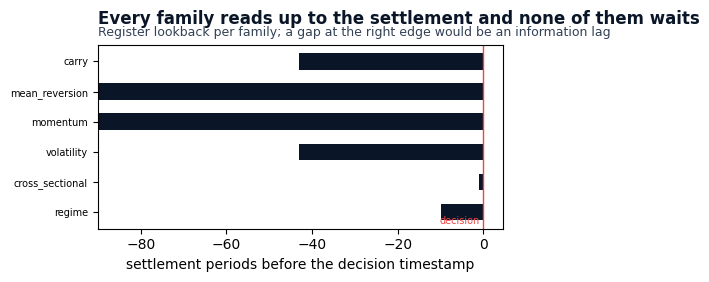

In [18]:
plot_timing_contract(
    FAMILIES,
    bar_unit="settlement periods",
    title="Every family reads up to the settlement and none of them waits",
    subtitle="Register lookback per family; a gap at the right edge would be an information lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision line "
        "by that family's lookback: ninety settlement periods for momentum and mean reversion, "
        "forty-three for carry and volatility, ten for regime and one for the cross-sectional "
        "family. Every bar reaches the decision line, and there is no hatched lag segment on any "
        "of them."
    ),
)

The matrix carries **39 features** on **99,877 rows** across **19 perpetuals**, from
**2020-01-31** to **2025-12-31**, under content digest **873623a4af13b3fc**. Assembly discarded
**8,421** of the **108,298** settlement bars the panel starts with, and the **537** missing
premium-index observations in the input account for most of that rather than the warmup does.

In [19]:
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['symbol'].n_unique()} perps"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}")

39 features, 99,877 rows, 19 perps
2020-01-31 08:00:00+00:00 to 2025-12-31 16:00:00+00:00


## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. All four are descriptive, and none of them reads a
label. Whether a feature predicts is a fold-aware question, and `05_evaluation` is where it is
asked.

### F2. Feature distributions

The percentile panel is a comb rather than the flat block a percentile usually draws, and that is
the cross-section showing through: nineteen perpetuals admit at most nineteen distinct positions
per settlement, and the panel is unbalanced, so the values it can take change with breadth. It is
still comparable across dates, which is the property it was built for, but a model that expects a
continuous input is being handed something closer to an ordered category.

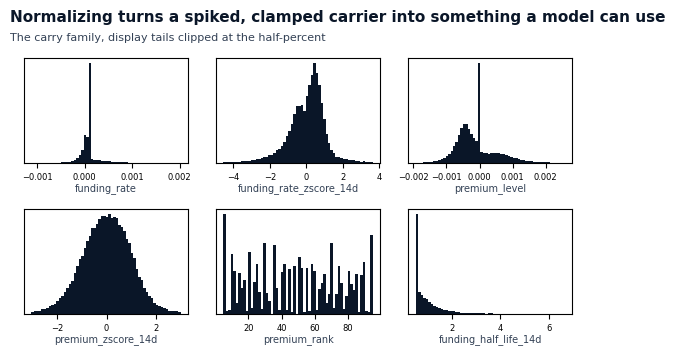

In [20]:
plot_feature_distributions(
    features,
    [
        "funding_rate",
        "funding_rate_zscore_14d",
        "premium_level",
        "premium_zscore_14d",
        "premium_rank",
        "funding_half_life_14d",
    ],
    title="Normalizing turns a spiked, clamped carrier into something a model can use",
    subtitle="The carry family, display tails clipped at the half-percent",
    alt=(
        "Six histograms in two rows. The raw funding rate and the premium level are both a narrow "
        "spike at zero with thin tails either side, and almost no usable spread. Their trailing "
        "z-scores are broad: the funding z-score peaks just above zero and trails off to the left "
        "to about minus four, the premium z-score is close to symmetric between minus three and "
        "three. The cross-sectional percentile is not smooth but a comb of isolated bars spread "
        "evenly across the range. The half-life is concentrated at the short end, with a tall bar "
        "at the lower clip and a body that thins out over the first few settlements."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a settlement where the band
narrows to nothing there is nothing to rank, whatever the average level of funding that day.

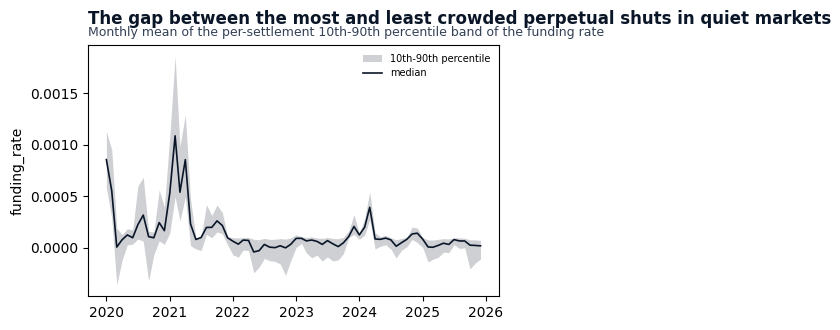

In [21]:
plot_cross_sectional_dispersion(
    features,
    "funding_rate",
    every="1mo",
    title="The gap between the most and least crowded perpetual shuts in quiet markets",
    subtitle="Monthly mean of the per-settlement 10th-90th percentile band of the funding rate",
    alt=(
        "Shaded band of the 10th to 90th percentile of the realized funding rate per settlement, "
        "averaged by month, with the median drawn through it. The band is widest through 2020 and "
        "2021, peaking sharply in the first quarter of 2021, then narrows to close to nothing "
        "from 2022 onward with only a brief reopening in early 2024. The median tracks the band "
        "and sits a little above zero for almost the whole sample."
    ),
)

### F5. Redundancy structure

Clustering on the distance $1 - |\rho|$ groups features that carry the same ordering, whatever
the sign. Above the cut two features are close enough that a linear model cannot separate their
contributions. This states the clusters. Picking one representative from each is a fold-aware
choice, and `05_evaluation` is where it is made.

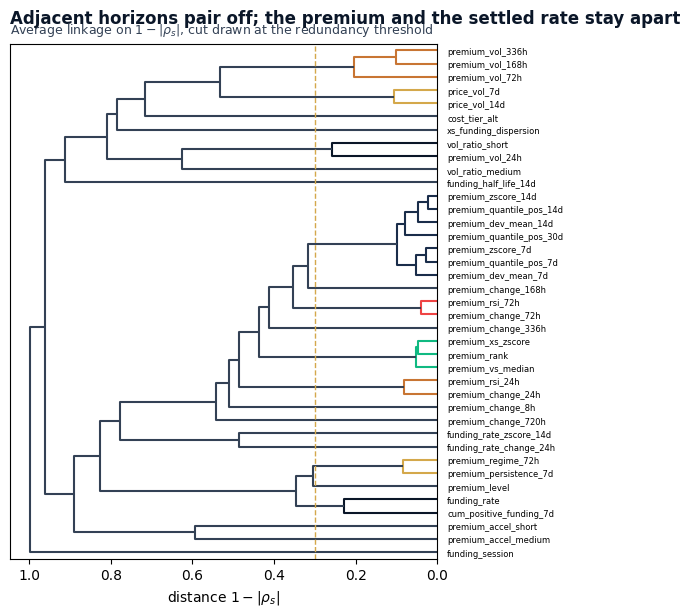

In [22]:
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=REDUNDANCY_CUT,
    title="Adjacent horizons pair off; the premium and the settled rate stay apart",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at the redundancy threshold",
    alt=(
        "Dendrogram of all 39 features. The cut leaves 23 clusters, nine of which hold more than "
        "one feature. The largest is the normalized premium block, seven columns joined above the "
        "cut: both z-scores, all three percentile positions, and both deviations from a trailing "
        "mean. Two clusters hold three features each - the three premium volatility windows, and "
        "a cross-sectional group of the premium rank, the premium against the cross-sectional "
        "median, and the cross-sectional z-score. The other six are pairs: the realized funding "
        "rate with its seven-day cash flow; each oscillator with the premium change over its own "
        "window, once at one day and once at three; the regime indicator with premium "
        "persistence; the one-day premium volatility with the short volatility ratio; and the two "
        "price volatility windows. The remaining fourteen features stand alone and merge only "
        "near the root, among them the medium volatility ratio, the funding dispersion, the "
        "session marker and the premium level."
    ),
)

### F6. Persistence and rank stability

The autocorrelation on the left is of the feature, not of any return. A feature whose value has
decayed inside one rebalance cycle cannot support that cadence, however well it predicts at the
settlement it is computed on. It is estimated per perpetual on pairs of settlements exactly one
lag apart and summarized by the median over perpetuals, with a bootstrap interval: a correlation
pooled over every symbol-settlement pair would read high whenever symbols sit at different
levels, whether or not any one of them persists. The right-hand panel asks the same question of
the ordering rather than the level, across consecutive rebalances - which here are consecutive
settlements, because that is the cadence this case study trades at.

Two readings are worth taking from it. The trailing statistics keep their ordering and the
normalized premium carriers do not, so the carriers are usable at this cadence and would not be
at a slower one - the eight-hour rebalance is doing work the register cannot show. And the
oscillator turns negative at a lag equal to its own window, which is what a bounded average of a
fixed number of differences does when the differences themselves carry no memory: it is measuring
its own window rather than the market's.

Binance stamps to the millisecond and every artifact here carries that precision. The figure maps
timestamps through a Python dictionary, which returns microseconds and will not join against a
millisecond column, so the frame handed to it is cast first. Only that frame; the emitted matrix
keeps the precision its siblings read.

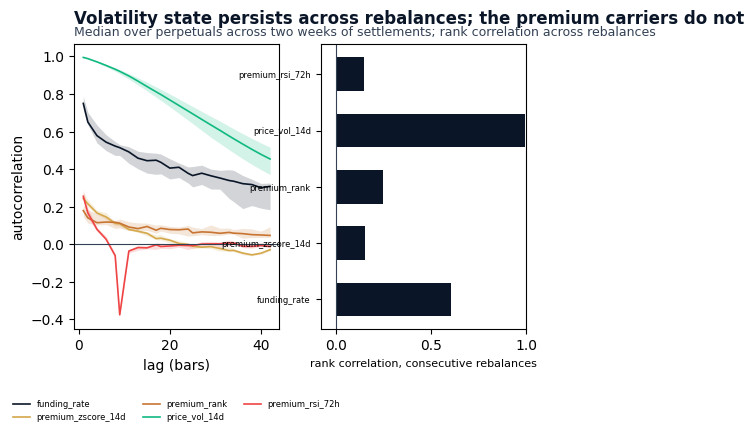

In [23]:
persistence_frame = features.with_columns(pl.col("timestamp").cast(pl.Datetime("us", "UTC")))
DECISION_DATES = persistence_frame["timestamp"].unique().sort().to_list()

plot_persistence(
    persistence_frame,
    ["funding_rate", "premium_zscore_14d", "premium_rank", "price_vol_14d", "premium_rsi_72h"],
    entity="symbol",
    max_lag=W["premium_zscore"]["14d"],
    decision_dates=DECISION_DATES,
    title="Volatility state persists across rebalances; the premium carriers do not",
    subtitle="Median over perpetuals across two weeks of settlements; rank correlation across rebalances",
    alt=(
        "Two panels. On the left, autocorrelation against lag. The two-week price volatility "
        "starts at one and decays slowly to about 0.45 at the longest lag. The realized funding "
        "rate starts near 0.75 and falls to about 0.25. The premium z-score and the "
        "cross-sectional percentile both start near 0.25 and are at zero within about twenty "
        "settlements. The oscillator falls fastest, crossing zero and reaching about minus 0.35 "
        "at a lag equal to its own window before returning to zero. Bootstrap ribbons are narrow "
        "throughout. On the right, the rank correlation between consecutive rebalances orders "
        "them the same way: price volatility at one, the funding rate around 0.6, the percentile "
        "around 0.25, and the z-score and the oscillator both near 0.15."
    ),
)

Read together, the four figures say the matrix is usable, redundant, and short-lived. The
cross-section disagrees except in the quietest stretches, where there is little to rank; the
redundancy cut leaves **23** distinct orderings among **39** columns; and only the trailing
volatility and the raw settled rate keep their ordering from one settlement to the next, while
the normalized premium carriers turn over almost completely. That is a constraint on cadence
rather than a defect: the carriers are usable at the eight-hour rebalance this case study trades
and would carry nothing at a weekly one.

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digests of what it was built from. The digest is computed over content rather
than file bytes, so row order and parquet metadata leave it alone and any feature value moves it.
That is the property the registry's own hashes lack: a feature-set *name* reaches the registry, a
feature-set *value* does not, so a corrected feature moves every number downstream without
changing anything the registry stores.

In [24]:
FEATURES_DIR.mkdir(parents=True, exist_ok=True)
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=["symbol", "timestamp"],
    written_by="case_studies/crypto_perps_funding/03_financial_features.py",
    inputs={
        "load_crypto_perps": value_digest(prices),
        "load_funding_rates": value_digest(funding),
    },
)
# Named relative to the repository rather than passed through `display_path`, which resolves
# symlinks before relativizing: an agent worktree points its artifact directories at the canonical
# store, so the resolved path lands outside the repo and gets printed absolute into the commit.
print(f"Wrote case_studies/crypto_perps_funding/features/financial.parquet, {record['digest']}")
print(f"{len(set(clusters.values()))} redundancy clusters at the cut drawn in F5")

Wrote case_studies/crypto_perps_funding/features/financial.parquet, 873623a4af13b3fc
23 redundancy clusters at the cut drawn in F5


## Key takeaways

- **Move the clock before you build anything.** A provider stamps a bar with the time it opened;
  a feature has to be stamped with the time it became knowable. Every shift, join and window
  here inherits that one decision, and `02_labels` makes the same one.
- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and any
  review a reader runs read those numbers rather than re-deriving them from the code.
- **Test the seal by construction, not by inspection.** Rebuilding the panel with the holdout
  withheld catches any transform fitted across the sample, including the ones nobody flagged.
- **Normalize what the exchange distorts.** The settled rate is clamped and spiked; its trailing
  z-score and its position within the settlement stay comparable across symbols and regimes, and
  F6 is where that difference shows up as persistence.

### Known limitations

- The universe is a fixed nineteen-symbol research panel rather than a point-in-time liquidity
  ranking, a selection bias `01_feasibility_analysis` documents and this notebook inherits.
- The fee tier is a fixed list in the configuration. A perpetual that changed tier during the
  sample carries the wrong one for part of it.
- The funding rate is knowable at the settlement instant and not before it, so a strategy that
  wanted to act ahead of a settlement would have to use the premium-index features alone.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.